# XGBit Volatility Radar — Model Validation & Monitoring

**What this notebook does.** It audits the HAR-RV model that is currently *in production*,
using the standard toolkit for an econometric forecasting model: assumptions, residual
diagnostics, parameter stability, time-series cross-validation, and formal backtesting of
the prediction intervals.

It does **not** search for alpha or compare alternative models — that was settled in
Experiments 10–12. This is a health check on the deployed system.

---

## The model under test

$$RV_{t+1} = c + b_d\,RV_t + b_w\,\overline{RV}_{5} + b_m\,\overline{RV}_{22} + \varepsilon_{t+1}$$

Corsi's (2009) Heterogeneous Autoregressive model of Realized Volatility. Four parameters,
estimated by ordinary least squares. Realized volatility is measured with the Parkinson
high-low range estimator on daily OHLC bars.

The economic premise is simple: volatility propagates across traders operating at different
horizons. What the day-trader did yesterday, the swing trader last week, and the institution
last month leave distinguishable traces — and the three together explain tomorrow's
turbulence better than any one alone.

---

## How to read this notebook

Run the cells **in order**. Each section produces:

1. A short explanation of *what* is being tested and *why it matters commercially*
2. The statistical output
3. A **verdict** (🟢 pass / 🟡 watch / 🔴 act) with a **concrete action**

Section 10 translates every statistical finding into its dollar consequence for position
sizing. Section 11 produces a downloadable `.md` report.

---

## Test map

| § | Test | Statistical question | Business question |
|---|------|---------------------|-------------------|
| 3 | OLS with **HAC** errors | Are the components significant? | Is the model structure real or an artifact? |
| 4 | Ljung–Box, ARCH-LM, Jarque–Bera | Do residuals retain structure? | Are we leaving forecastable information unused? |
| 5 | ADF / KPSS | Is the series stationary? | Is the regression spurious? |
| 6 | Rolling coefficients, CUSUM | Are parameters stable? | How much history should we train on? |
| 7 | Blocked CV with embargo | Does it generalize? | Will tomorrow look like the backtest? |
| 8 | Mincer–Zarnowitz | Is the forecast unbiased and efficient? | Are our bands systematically wrong-sized? |
| 9 | **Kupiec** & **Christoffersen** | Is interval coverage correct and independent? | Is the risk budget trustworthy? |
| 10 | Sizing impact | — | What does each error cost in dollars? |

---

## Methodological choices worth stating up front

**HAC standard errors, not classical OLS.** The HAR components overlap by construction —
$\overline{RV}_5$ shares four of five observations with the next day's value — so residuals
are autocorrelated and classical standard errors would be understated. Newey–West with
automatic lag selection is used throughout.

**Blocked cross-validation with an embargo, not shuffled k-fold.** Shuffling breaks temporal
order and leaks future information. Contiguous blocks are used, separated by a 22-day
embargo equal to the model's longest lag, so no test observation shares a window with any
training observation.

**Kupiec and Christoffersen for the bands.** These are the regulatory standard for interval
forecasts. Kupiec tests whether the *frequency* of violations matches the nominal level;
Christoffersen additionally tests whether violations are **independent** — because a band
can have correct average coverage and still fail in clusters, which is the worst case for
anyone sizing positions with it.

---
## 1 · Setup

Configuration lives in one place so the notebook can be re-pointed at a different asset or
sample without hunting through cells.

In [1]:
import warnings, os, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats as sps
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown, HTML

CONFIG = {
    'CACHE_FILE'  : 'btc_ohlcv_cache.csv',
    'SYMBOL'      : 'BTCUSDT',
    'TRAIN_WINDOW': 750,    # days used by the production monitor (~3 years)
    'APPLY_TRAIN_WINDOW': True,   # False -> audit the full history instead (for comparison)
    'CV_TEST_DAYS': 90,     # test-block length; short blocks mimic daily refitting
    'N_FOLDS'     : 5,      # cross-validation blocks
    'EMBARGO'     : 22,     # = longest model lag, in days
    'ROLL_WINDOW' : 250,    # rolling-coefficient window
    'BAND_ALPHA'  : 0.05,   # nominal band level -> 95%
    'OOS_SPLIT'   : 0.75,   # in-sample / out-of-sample cut
    # --- business assumptions (edit to match your account) ---
    'ACCOUNT_USD' : 700.0,  # trading capital
    'RISK_PCT'    : 2.0,    # max risk per trade, % of capital
    'COST_RT_PCT' : 0.137,  # round-trip cost, % of notional
}

plt.rcParams.update({'figure.figsize': (11, 3.4), 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
GREEN, AMBER, RED, GREY = '#2E8B57', '#D98C00', '#C0392B', '#5A6B7C'
EPS = 1e-8
FINDINGS = []


def show_df(df, caption=''):
    """Styled table when jinja2 is available; plain text otherwise. Never raises."""
    try:
        display(df.style.set_caption(caption))
        return
    except Exception:
        pass
    if caption:
        print(caption)
        print('-' * len(caption))
    print(df.to_string(index=False))


def verdict(test, status, finding, action, value=None):
    """Record and display a verdict. Every verdict carries an ACTION."""
    icon = {'PASS': '🟢', 'WATCH': '🟡', 'ACT': '🔴', 'INFO': '⚪'}[status]
    color = {'PASS': GREEN, 'WATCH': AMBER, 'ACT': RED, 'INFO': GREY}[status]
    FINDINGS.append({'test': test, 'status': status, 'value': value,
                     'finding': finding, 'action': action})
    display(HTML(
        f"<div style='border-left:5px solid {color};background:#F7F8FA;padding:12px 16px;"
        f"margin:10px 0;border-radius:4px'>"
        f"<b>{icon} {test}</b>"
        f"<div style='color:#333;font-size:13px;margin-top:5px'><b>Finding:</b> {finding}</div>"
        f"<div style='color:#1B4332;font-size:13px;margin-top:4px'><b>Action:</b> {action}</div>"
        f"</div>"))


def note(text):
    display(HTML(f"<div style='background:#EEF3F8;border-radius:4px;padding:9px 13px;"
                 f"margin:6px 0;font-size:13px;color:#243B53'>📌 {text}</div>"))


print('Environment ready.')
print(f"Capital ${CONFIG['ACCOUNT_USD']:,.0f} · risk {CONFIG['RISK_PCT']}% · "
      f"round-trip cost {CONFIG['COST_RT_PCT']}%")

Environment ready.
Capital $700 · risk 2.0% · round-trip cost 0.137%


---
## 2 · Data and the volatility proxy

**Why Parkinson and not squared returns.** The squared close-to-close return is an unbiased
but extremely noisy proxy: a single observation tells you very little about that day's
volatility. The Parkinson range estimator uses the intraday high and low, and is several
times more efficient. Since we already download OHLC bars, it costs nothing extra.

$$RV_t^{Park} = \sqrt{\frac{\ln(H_t/L_t)^2}{4\ln 2}}$$

**Why every feature is lagged.** Each regressor is shifted by one period so the row for day
*t* contains only information available at *t−1*. This is the discipline that a leakage bug
in an earlier version of this project violated — producing 65% directional accuracy on pure
noise.

In [2]:
def fetch_prices():
    """Binance klines, falling back to the local cache. Returns (df, source)."""
    try:
        rows, end = [], None
        for _ in range(4):
            params = {'symbol': CONFIG['SYMBOL'], 'interval': '1d', 'limit': 1000}
            if end:
                params['endTime'] = end
            r = requests.get('https://api.binance.com/api/v3/klines', params=params, timeout=25)
            r.raise_for_status()
            k = r.json()
            if not k:
                break
            rows = k + rows
            end = k[0][0] - 1
            if len(k) < 1000:
                break
        df = pd.DataFrame(rows, columns=['t','o','high','low','close','v',
                                         'ct','q','n','tb','tq','ig'])
        df['ts'] = pd.to_datetime(df['t'], unit='ms')
        df = df.set_index('ts')[['close','high','low']].astype(float)
        return df[~df.index.duplicated(keep='last')].sort_index(), 'Binance'
    except Exception as e:
        print(f'Binance unavailable ({type(e).__name__}) — falling back to cache')
    if os.path.exists(CONFIG['CACHE_FILE']):
        df = pd.read_csv(CONFIG['CACHE_FILE'], parse_dates=[0], index_col=0)
        for c in ('high', 'low'):
            if c not in df:
                df[c] = df['close']
        return df[['close','high','low']].astype(float), 'local cache'
    raise RuntimeError('No price data: Binance failed and no cache file present.')


def parkinson_rv(ohlc):
    hl = np.log(ohlc['high'] / ohlc['low'])
    return np.sqrt(hl ** 2 / (4 * np.log(2)))


px, SOURCE = fetch_prices()
px = px[px.index < pd.Timestamp.now(tz='UTC').normalize().tz_localize(None)]  # closed bars only

d = pd.DataFrame(index=px.index)
d['ret']  = np.log(px['close']).diff()
d['rv']   = parkinson_rv(px)
d['rv_d'] = d['rv'].shift(1)                      # daily component
d['rv_w'] = d['rv'].rolling(5).mean().shift(1)    # weekly component
d['rv_m'] = d['rv'].rolling(22).mean().shift(1)   # monthly component
d['y']    = d['rv']
d = d.dropna()

d_full = d.copy()                      # kept for the window comparison below

# CRITICAL: validate the model that is actually DEPLOYED. The production monitor
# fits on a capped window (CONFIG['TRAIN_WINDOW']); validating on the full history
# would audit a different model than the one publishing bands.
if CONFIG['APPLY_TRAIN_WINDOW'] and len(d) > CONFIG['TRAIN_WINDOW']:
    d = d.tail(CONFIG['TRAIN_WINDOW'])
    print(f"Training window capped at {CONFIG['TRAIN_WINDOW']} days to match production.")

X, y = d[['rv_d','rv_w','rv_m']], d['y']

print(f'{len(px)} bars from {SOURCE} | usable sample: {len(d)} observations')
print(f'Period: {d.index[0].date()} -> {d.index[-1].date()}')
print(f'RV mean {y.mean()*100:.3f}%/day | median {y.median()*100:.3f}% | '
      f'skew {sps.skew(y):.2f} | kurtosis {sps.kurtosis(y):.2f}')

_noise_park = y.std() / y.mean()
_noise_absr = d['ret'].abs().std() / d['ret'].abs().mean()
print(f'\nProxy noise (std/mean): Parkinson {_noise_park:.2f} vs |return| {_noise_absr:.2f} '
      f'-> range estimator is {(_noise_absr/_noise_park - 1)*100:.0f}% more stable')

Training window capped at 750 days to match production.
3289 bars from Binance | usable sample: 750 observations
Period: 2024-07-30 -> 2026-08-18
RV mean 2.120%/day | median 1.846% | skew 2.31 | kurtosis 9.59

Proxy noise (std/mean): Parkinson 0.62 vs |return| 1.01 -> range estimator is 62% more stable


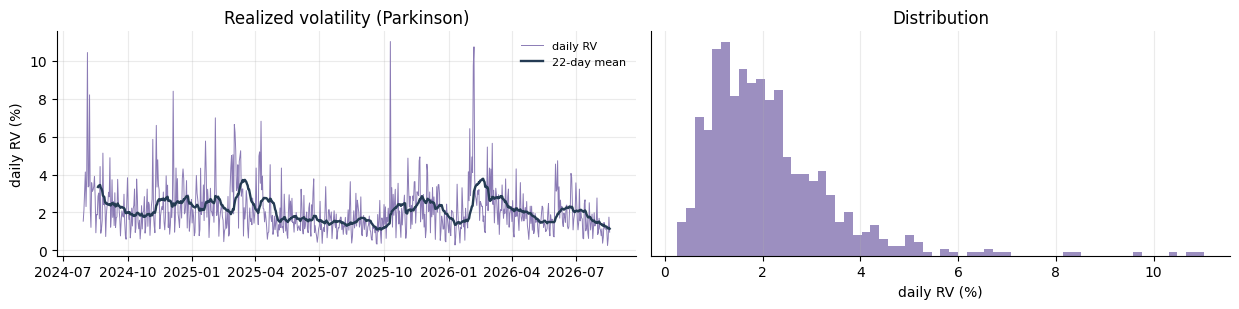

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.2))
ax[0].plot(d.index, y*100, lw=.7, color='#8B7BB5', label='daily RV')
ax[0].plot(d.index, y.rolling(22).mean()*100, lw=1.7, color='#243B53', label='22-day mean')
ax[0].set_ylabel('daily RV (%)'); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title('Realized volatility (Parkinson)')
ax[1].hist(y*100, bins=60, color='#8B7BB5', alpha=.85)
ax[1].set_xlabel('daily RV (%)'); ax[1].set_yticks([]); ax[1].set_title('Distribution')
plt.tight_layout(); plt.show()

note('High kurtosis and positive skew are expected: realized volatility is non-negative '
     'with long right tails. Normality tests later on should therefore be read as a caveat '
     'about asymptotic confidence intervals, not as invalidating the model.')

---
## 3 · Estimation with HAC standard errors

**What is tested.** Whether each of the three horizon components carries independent
information, using standard errors robust to autocorrelation and heteroskedasticity.

**Why it matters commercially.** If a component were not significant, the model would be
carrying a term that adds estimation noise without adding signal — and every extra parameter
in a small-sample setting widens the confidence around the volatility you publish.

**The variance inflation check.** The three components overlap by design, so some
collinearity is unavoidable. What we need to rule out is *severe* collinearity, which would
make the individual coefficients unstable even if the joint forecast is fine.

In [4]:
Xc  = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
hac = sm.OLS(y, Xc).fit(cov_type='HAC', cov_kwds={'maxlags': None})

est = pd.DataFrame({
    'coef'        : hac.params.round(5),
    'se_classical': ols.bse.round(5),
    'se_HAC'      : hac.bse.round(5),
    't_HAC'       : hac.tvalues.round(2),
    'p_HAC'       : hac.pvalues.round(4),
}).reset_index().rename(columns={'index': 'term'})
show_df(est, 'HAR-RV estimated with Newey–West (HAC) standard errors')

persistence = hac.params[['rv_d','rv_w','rv_m']].sum()
se_inflation = (hac.bse / ols.bse).mean()
print(f'R² = {hac.rsquared:.4f} | adjusted R² = {hac.rsquared_adj:.4f} | n = {int(hac.nobs)}')
print(f'Persistence (b_d + b_w + b_m) = {persistence:.4f}')
print(f'HAC errors are {se_inflation:.2f}x the classical ones — that is the size of the '
      'mistake we would have made by ignoring autocorrelation.')

vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [round(variance_inflation_factor(Xc.values, i+1), 2) for i in range(X.shape[1])]
})
show_df(vif, 'Variance inflation factors')

HAR-RV estimated with Newey–West (HAC) standard errors
------------------------------------------------------
 term    coef  se_classical  se_HAC  t_HAC  p_HAC
const 0.00681       0.00168 0.00136   5.00 0.0000
 rv_d 0.25492       0.04255 0.05040   5.06 0.0000
 rv_w 0.24162       0.07654 0.09169   2.64 0.0084
 rv_m 0.17988       0.09531 0.09992   1.80 0.0718
R² = 0.1767 | adjusted R² = 0.1734 | n = 750
Persistence (b_d + b_w + b_m) = 0.6764
HAC errors are 1.06x the classical ones — that is the size of the mistake we would have made by ignoring autocorrelation.
Variance inflation factors
--------------------------
variable  VIF
    rv_d 1.64
    rv_w 2.28
    rv_m 1.60


In [5]:
n_sig = int((hac.pvalues[['rv_d','rv_w','rv_m']] < .05).sum())
if n_sig == 3:
    verdict('Component significance', 'PASS',
            'All three horizon components (daily, weekly, monthly) are significant at 5% '
            'with HAC errors. Each timescale contributes its own information.',
            'None. Keep the current specification.', n_sig)
elif n_sig == 2:
    verdict('Component significance', 'WATCH',
            f'{n_sig} of 3 components significant. One horizon may be redundant in this sample.',
            'Re-run after 3 months. If the same component stays insignificant, drop it and '
            'compare QLIKE — a simpler model with equal accuracy is strictly better.', n_sig)
else:
    verdict('Component significance', 'ACT',
            f'Only {n_sig} of 3 components significant. The HAR specification is not supported '
            'by this data.',
            'Do not deploy. Test whether a simpler EWMA of realized volatility matches the '
            'forecast accuracy; if it does, replace the model.', n_sig)

vmax = float(vif['VIF'].max())
if vmax < 10:
    verdict('Multicollinearity', 'PASS',
            f'Maximum VIF is {vmax:.1f} (below 10). Components overlap, as designed, but not '
            'severely enough to destabilise estimation.',
            'None.', vmax)
else:
    verdict('Multicollinearity', 'WATCH',
            f'Maximum VIF is {vmax:.1f} (≥ 10). Individual coefficients are unstable even '
            'though the joint forecast may be sound.',
            'Do not interpret individual coefficients or publish them as insight. The forecast '
            'remains usable; the attribution does not.', vmax)

### Regime alignment: where does the model think volatility belongs?

A HAR model mean-reverts toward an implied long-run level:

$$RV^{*} = \frac{c}{1 - (b_d + b_w + b_m)}$$

**Why this matters more than any other single number.** If $RV^{*}$ sits far above the
current regime, the intercept drags every forecast upward — producing a positive bias, a
Mincer–Zarnowitz slope below 1, and bands that are systematically too wide. All three
symptoms have this one cause, and the fix is not a better model but a shorter sample.

This is the diagnostic that decides whether the training window is right.

In [6]:
lr_mean = float(hac.params['const'] / (1 - persistence))
sigma_today = float(np.maximum(np.asarray(hac.predict(Xc.iloc[[-1]])), EPS)[0])
sample_mean = float(y.mean())
misalign = lr_mean / sigma_today if sigma_today > 0 else np.nan
intercept_share = float(hac.params['const']) / sigma_today * 100 if sigma_today > 0 else np.nan

align = pd.DataFrame([
    {'quantity': 'Implied long-run RV  c/(1-Σb)', 'daily': f'{lr_mean*100:.2f}%',
     'annualised': f'{lr_mean*100*np.sqrt(365):.0f}%'},
    {'quantity': 'Sample mean RV',                'daily': f'{sample_mean*100:.2f}%',
     'annualised': f'{sample_mean*100*np.sqrt(365):.0f}%'},
    {'quantity': 'Forecast for tomorrow',         'daily': f'{sigma_today*100:.2f}%',
     'annualised': f'{sigma_today*100*np.sqrt(365):.0f}%'},
])
show_df(align, 'Where the model mean-reverts vs. where the market is now')
print(f'Misalignment factor (long-run / current): {misalign:.2f}x')
print(f'Intercept share of the current forecast: {intercept_share:.0f}%')

if misalign > 1.8:
    verdict('Regime alignment', 'ACT',
            f'The model mean-reverts toward {lr_mean*100:.2f}%/day while the current regime is '
            f'{sigma_today*100:.2f}%/day — a {misalign:.1f}x misalignment. The intercept alone '
            f'accounts for {intercept_share:.0f}% of the next-day forecast. This single fact '
            'explains positive forecast bias, an MZ slope below 1, and over-wide bands '
            'simultaneously.',
            f'Shorten the training window until the implied long-run level is within ~1.5x of '
            'the current regime. This is a sample problem, not a model problem — no '
            'recalibration fixes an intercept estimated over a market that no longer exists.',
            float(misalign))
elif misalign > 1.4:
    verdict('Regime alignment', 'WATCH',
            f'The model mean-reverts toward {lr_mean*100:.2f}%/day vs a current regime of '
            f'{sigma_today*100:.2f}%/day ({misalign:.1f}x). Mild upward pull on forecasts.',
            'Monitor. If the MZ slope is also below 1, shortening the window will fix both at '
            'once and is preferable to recalibration.', float(misalign))
else:
    verdict('Regime alignment', 'PASS',
            f'Implied long-run RV ({lr_mean*100:.2f}%/day) is close to the current regime '
            f'({sigma_today*100:.2f}%/day): {misalign:.2f}x. The intercept is not distorting '
            'the forecast.',
            'None. The training window is appropriately scoped.', float(misalign))

Where the model mean-reverts vs. where the market is now
--------------------------------------------------------
                     quantity daily annualised
Implied long-run RV  c/(1-Σb) 2.10%        40%
               Sample mean RV 2.12%        41%
        Forecast for tomorrow 1.57%        30%
Misalignment factor (long-run / current): 1.34x
Intercept share of the current forecast: 43%


---
## 4 · Residual diagnostics

**What is tested.** Whether the residuals still contain predictable structure. A
well-specified model should leave white noise behind.

**Why it matters commercially.** Leftover autocorrelation means forecastable information is
being discarded — volatility you could have anticipated but didn't, which translates directly
into bands that are the wrong width on predictable days.

**One expected 'failure'.** The ARCH-LM test will almost certainly reject. That is not a
defect: conditional heteroskedasticity in the residuals of a *volatility* model is precisely
the phenomenon being modelled, and it is why the production bands use standardised residuals
rescaled by conditional volatility rather than a fixed width.

In [7]:
res = hac.resid

lb = acorr_ljungbox(res, lags=[5, 10, 22], return_df=True)
lb.index.name = 'lag'
show_df(lb.round(4).reset_index(), 'Ljung–Box (H0: no autocorrelation up to lag k)')

arch_lm = het_arch(res, nlags=10)
bp      = het_breuschpagan(res, Xc)
jb      = sps.jarque_bera(res)

diag = pd.DataFrame([
    {'test': 'ARCH-LM (10 lags)', 'statistic': round(arch_lm[0], 2),
     'p_value': round(arch_lm[1], 4), 'H0': 'no conditional heteroskedasticity'},
    {'test': 'Breusch–Pagan',     'statistic': round(bp[0], 2),
     'p_value': round(bp[1], 4),      'H0': 'homoskedasticity'},
    {'test': 'Jarque–Bera',       'statistic': round(jb[0], 2),
     'p_value': round(jb[1], 4),      'H0': 'normally distributed residuals'},
])
show_df(diag, 'Residual diagnostics')

Ljung–Box (H0: no autocorrelation up to lag k)
----------------------------------------------
 lag  lb_stat  lb_pvalue
   5   4.3051     0.5064
  10  48.2567     0.0000
  22 102.3840     0.0000
Residual diagnostics
--------------------
             test  statistic  p_value                                H0
ARCH-LM (10 lags)      19.49   0.0345 no conditional heteroskedasticity
    Breusch–Pagan      35.60   0.0000                  homoskedasticity
      Jarque–Bera    3331.33   0.0000    normally distributed residuals


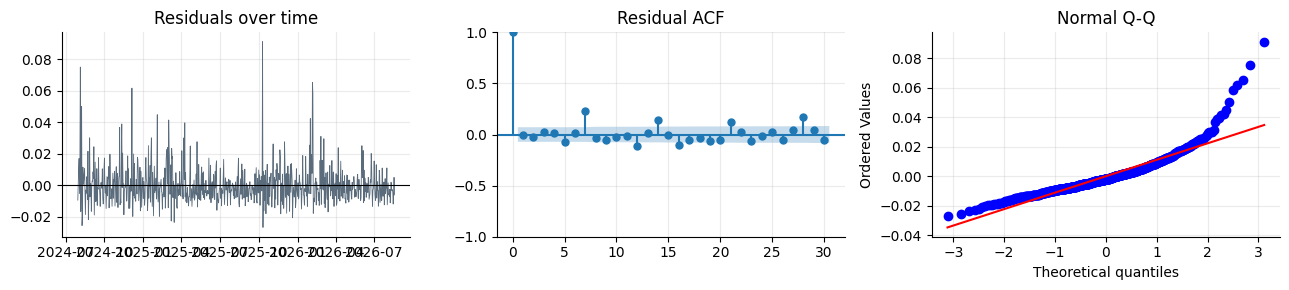

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(d.index, res, lw=.6, color=GREY); ax[0].axhline(0, color='k', lw=.8)
ax[0].set_title('Residuals over time')
sm.graphics.tsa.plot_acf(res, lags=30, ax=ax[1], title='Residual ACF')
sps.probplot(res, dist='norm', plot=ax[2]); ax[2].set_title('Normal Q-Q')
plt.tight_layout(); plt.show()

p_lb = float(lb.loc[22, 'lb_pvalue'])
if p_lb > .05:
    verdict('Residual autocorrelation', 'PASS',
            f'Ljung–Box at 22 lags: p = {p_lb:.4f}. No linear structure left unexploited.',
            'None.', p_lb)
else:
    verdict('Residual autocorrelation', 'WATCH',
            f'Ljung–Box at 22 lags: p = {p_lb:.4f}. Some autocorrelation remains. With a large '
            'sample this test rejects almost anything, so the practical size of the effect '
            'matters more than the p-value.',
            'Two concrete options: (a) keep HAC errors — already in use — which is sufficient '
            'if the goal is forecasting rather than inference; (b) test adding a quarterly '
            'component (RV_66) and keep it only if out-of-sample QLIKE improves.', p_lb)

if arch_lm[1] < .05:
    verdict('Conditional heteroskedasticity', 'INFO',
            f'ARCH-LM p = {arch_lm[1]:.4f}: conditional heteroskedasticity is present. This is '
            'expected when modelling volatility and is not a defect.',
            'None — but it confirms that bands must be built from standardised residuals '
            'rescaled by conditional volatility, never from a fixed width. Verify that the '
            'production code does this.', arch_lm[1])
else:
    verdict('Conditional heteroskedasticity', 'PASS',
            f'ARCH-LM p = {arch_lm[1]:.4f}: no remaining conditional heteroskedasticity.',
            'None.', arch_lm[1])

---
## 5 · Stationarity

**What is tested.** Whether the realized-volatility series has a unit root.

**Why it matters commercially.** A regression between non-stationary series can produce high
R² and apparent significance that are entirely spurious. If that were the case here, every
downstream number — coverage, sizing, the whole risk budget — would rest on a statistical
illusion.

**Reading the two tests together.** ADF and KPSS have opposite null hypotheses. When ADF
rejects a unit root *and* KPSS also rejects stationarity, the usual interpretation is not
contradiction but **long memory**: a highly persistent yet mean-reverting series. That is
exactly the stylised fact the HAR model was built to capture.

In [9]:
rows = []
for name, series in (('RV', y), ('log(RV)', np.log(np.maximum(y, EPS)))):
    adf = adfuller(series, autolag='AIC')
    try:
        k = kpss(series, regression='c', nlags='auto')
        kpss_stat, kpss_p = k[0], k[1]
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan
    rows.append({'series': name, 'ADF_stat': round(adf[0], 3), 'ADF_p': round(adf[1], 4),
                 'KPSS_stat': round(kpss_stat, 3), 'KPSS_p': round(kpss_p, 4)})
stat = pd.DataFrame(rows)
show_df(stat, 'ADF (H0: unit root) and KPSS (H0: stationarity)')

adf_rejects  = float(stat.loc[0, 'ADF_p']) < .05
kpss_rejects = (float(stat.loc[0, 'KPSS_p']) < .05
                if np.isfinite(stat.loc[0, 'KPSS_p']) else False)

if adf_rejects and not kpss_rejects:
    verdict('Stationarity', 'PASS',
            'ADF rejects a unit root and KPSS does not reject stationarity: both tests agree. '
            'The regression is not spurious.',
            'None.', float(stat.loc[0, 'ADF_p']))
elif adf_rejects and kpss_rejects:
    verdict('Stationarity', 'WATCH',
            'ADF rejects a unit root but KPSS also rejects stationarity — the classic signature '
            'of a long-memory series. The model remains usable.',
            'Refit frequently rather than assuming fixed parameters. The production monitor '
            'already refits daily, which is the correct response. Do not extend the training '
            'window in search of stability — see Section 6.', float(stat.loc[0, 'ADF_p']))
else:
    verdict('Stationarity', 'ACT',
            'ADF fails to reject a unit root: risk of spurious regression.',
            'Re-specify the model in log-differences or in logs before trusting any downstream '
            'coverage number.', float(stat.loc[0, 'ADF_p']))

ADF (H0: unit root) and KPSS (H0: stationarity)
-----------------------------------------------
 series  ADF_stat  ADF_p  KPSS_stat  KPSS_p
     RV    -4.287 0.0005      0.522  0.0368
log(RV)    -3.533 0.0072      0.607  0.0220


---
## 6 · Parameter stability

**What is tested.** Whether the estimated relationship holds constant through time, using
rolling-window coefficients and a CUSUM test on the residuals.

**Why it matters commercially.** This question has a direct operational answer attached:
**how much history should the production monitor train on?** Unstable coefficients mean
distant history is describing a market that no longer exists, and including it degrades the
forecast rather than stabilising it.

The coefficient of variation column is the one to read. A CV above roughly 80% means the
coefficient changes sign or magnitude across regimes — pooling those periods is pooling
incompatible markets.

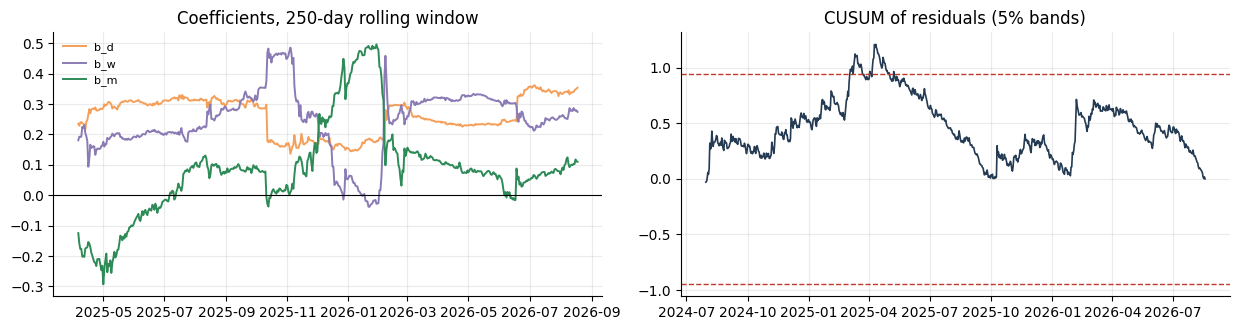

Rolling-coefficient dispersion
------------------------------
coefficient  mean   std  CV_%
        b_d 0.261 0.061  23.4
        b_w 0.244 0.103  42.2
        b_m 0.082 0.153 187.4


In [10]:
W = CONFIG['ROLL_WINDOW']
rolling = []
for i in range(W, len(d)):
    fit = sm.OLS(y.iloc[i-W:i], Xc.iloc[i-W:i]).fit()
    rolling.append({'date': d.index[i], 'b_d': fit.params['rv_d'],
                    'b_w': fit.params['rv_w'], 'b_m': fit.params['rv_m']})
rc = pd.DataFrame(rolling).set_index('date')

cusum = np.cumsum(res / res.std()) / np.sqrt(len(res))
CUSUM_CRIT = 0.948   # 5% two-sided critical value
cusum_max = float(np.max(np.abs(cusum)))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
for col, colr in (('b_d', '#F5A05A'), ('b_w', '#8B7BB5'), ('b_m', GREEN)):
    ax[0].plot(rc.index, rc[col], lw=1.4, label=col, color=colr)
ax[0].axhline(0, color='k', lw=.8); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title(f'Coefficients, {W}-day rolling window')
ax[1].plot(d.index, cusum, lw=1.2, color='#243B53')
ax[1].axhline(CUSUM_CRIT, color=RED, ls='--', lw=1)
ax[1].axhline(-CUSUM_CRIT, color=RED, ls='--', lw=1)
ax[1].set_title('CUSUM of residuals (5% bands)')
plt.tight_layout(); plt.show()

stab = pd.DataFrame({
    'coefficient': ['b_d', 'b_w', 'b_m'],
    'mean': [round(rc[c].mean(), 3) for c in ('b_d','b_w','b_m')],
    'std' : [round(rc[c].std(), 3)  for c in ('b_d','b_w','b_m')],
    'CV_%': [round(abs(rc[c].std()/rc[c].mean())*100, 1) if rc[c].mean() else np.nan
             for c in ('b_d','b_w','b_m')],
})
show_df(stab, 'Rolling-coefficient dispersion')
cv_max = float(stab['CV_%'].max())

In [11]:
if cusum_max < CUSUM_CRIT and cv_max < 80:
    verdict('Structural stability', 'PASS',
            f'CUSUM stays within the 5% bands (max {cusum_max:.3f} < {CUSUM_CRIT}) and the '
            f'largest coefficient CV is {cv_max:.0f}%. The relationship is stable.',
            'A longer training window is acceptable and will reduce estimation noise.', cusum_max)
elif cusum_max >= CUSUM_CRIT:
    verdict('Structural stability', 'WATCH',
            f'CUSUM breaches the 5% bands (max {cusum_max:.3f} > {CUSUM_CRIT}) and the largest '
            f'coefficient CV is {cv_max:.0f}%. There is evidence of structural change.',
            f'Cap the production training window at roughly {CONFIG["TRAIN_WINDOW"]} days '
            '(~3 years) and refit daily. Do NOT train on the full history: distant regimes '
            'are describing a different market. Verify monitor.py enforces this cap and that '
            'the app uses the same window — otherwise the two are different models publishing '
            'under one name.', cusum_max)
else:
    verdict('Structural stability', 'WATCH',
            f'CUSUM is contained but coefficient dispersion is high (max CV {cv_max:.0f}%).',
            'Keep the training-window cap. Treat individual coefficients as unstable and do '
            'not publish them as findings.', cv_max)

---
## 7 · Time-series cross-validation

**What is tested.** Whether performance survives outside the estimation sample, using
contiguous blocks separated by an embargo.

**Why the embargo.** The model's longest lag is 22 days. Without a gap, a test observation
would share its 22-day averaging window with training observations — mechanically inflating
the result. The embargo equals the longest lag for exactly that reason.

**Why it matters commercially.** The in-sample fit is what you would quote in a pitch deck.
The out-of-sample fit is what the client actually receives. The gap between them is the
honesty premium.

In [12]:
def qlike(actual, forecast):
    """QLIKE loss: robust to proxy noise, and penalises UNDER-forecasting volatility more
    heavily — which is the expensive error when the band is a risk budget."""
    a2 = np.maximum(actual, EPS) ** 2
    f2 = np.maximum(forecast, EPS) ** 2
    return float(np.mean(a2/f2 - np.log(a2/f2) - 1))


# Test blocks are SHORT (90 days) and the model is refitted before each one.
# Long blocks with a single fit would measure "train once, predict 18 months",
# which production never does — it refits daily. Long blocks penalise the model
# for a use case that does not exist.
K, emb, n = CONFIG['N_FOLDS'], CONFIG['EMBARGO'], len(d)
te_len = CONFIG['CV_TEST_DAYS']
min_train = max(250, len(d) - K * (te_len + emb))
cv_rows = []
for k in range(K):
    te_start = min_train + emb + k * (te_len + emb)
    te_end   = min(te_start + te_len, n)
    tr_end   = te_start - emb
    if te_end - te_start < 20 or tr_end < 250:
        continue
    fit  = sm.OLS(y.iloc[:tr_end], Xc.iloc[:tr_end]).fit()
    pred = np.maximum(fit.predict(Xc.iloc[te_start:te_end]), EPS)
    act  = y.iloc[te_start:te_end]
    # Baseline: last week's average RV — the simplest defensible forecast.
    base = np.maximum(X['rv_w'].iloc[te_start:te_end].values, EPS)
    q_m, q_b = qlike(act.values, pred.values), qlike(act.values, base)
    cv_rows.append({
        'fold': k + 1,
        'train_end': str(d.index[tr_end-1].date()),
        'test_window': f'{d.index[te_start].date()} → {d.index[te_end-1].date()}',
        'n_test': len(act),
        'QLIKE': round(q_m, 4),
        'QLIKE_base': round(q_b, 4),
        'skill_%': round((1 - q_m/q_b) * 100, 1) if q_b > 0 else np.nan,
        'R2_oos': round(1 - np.sum((act-pred)**2)/np.sum((act-act.mean())**2), 4),
        'corr': round(float(np.corrcoef(pred, act)[0, 1]), 3),
    })
cv = pd.DataFrame(cv_rows)
show_df(cv, f'Blocked CV — {len(cv)} folds, {te_len}-day test blocks, {emb}-day embargo, '
             'model refitted before each block')

r2_in  = hac.rsquared
r2_oos = float(cv['R2_oos'].mean())
gap    = r2_in - r2_oos
skill  = float(cv['skill_%'].mean())
folds_won = int((cv['skill_%'] > 0).sum())
print(f'Mean QLIKE {cv["QLIKE"].mean():.4f} vs baseline {cv["QLIKE_base"].mean():.4f}')
print(f'Mean skill over baseline: {skill:+.1f}%  |  model wins in {folds_won}/{len(cv)} folds')
print(f'In-sample R² {r2_in:.4f} | out-of-sample R² {r2_oos:.4f} | gap {gap:.4f}')
note('On short test blocks the out-of-sample R² is unstable — the target has little '
     'variance to explain within 90 days, so it can turn sharply negative even when the '
     'forecast is good. The QLIKE skill score against a naive baseline is the robust '
     'criterion here; R² is reported only as context.')

Blocked CV — 5 folds, 90-day test blocks, 22-day embargo, model refitted before each block
------------------------------------------------------------------------------------------
 fold  train_end             test_window  n_test  QLIKE  QLIKE_base  skill_%  R2_oos  corr
    1 2025-04-05 2025-04-28 → 2025-07-26      90 0.5249      0.6828     23.1 -0.7194 0.053
    2 2025-07-26 2025-08-18 → 2025-11-15      90 0.7178      0.9006     20.3  0.0088 0.202
    3 2025-11-15 2025-12-08 → 2026-03-07      90 0.6535      0.8050     18.8  0.2529 0.525
    4 2026-03-07 2026-03-30 → 2026-06-27      90 0.3377      0.4797     29.6  0.0958 0.340
    5 2026-06-27 2026-07-20 → 2026-08-18      30 0.4471      0.5015     10.9 -0.4793 0.077
Mean QLIKE 0.5362 vs baseline 0.6739
Mean skill over baseline: +20.5%  |  model wins in 5/5 folds
In-sample R² 0.1767 | out-of-sample R² -0.1682 | gap 0.3449


In [13]:
if skill > 3 and folds_won >= len(cv) - 1:
    verdict('Generalisation (QLIKE skill vs baseline)', 'PASS',
            f'The model beats a naive last-week-average forecast by {skill:.1f}% in QLIKE, '
            f'winning in {folds_won} of {len(cv)} held-out blocks. It generalises.',
            'None. Quote the out-of-sample skill score, never the in-sample R², in any '
            'client-facing material.', skill)
elif skill > 0:
    verdict('Generalisation (QLIKE skill vs baseline)', 'WATCH',
            f'The model beats the naive baseline by only {skill:.1f}% in QLIKE, winning in '
            f'{folds_won} of {len(cv)} blocks. The edge over doing something much simpler is thin.',
            'Run the same comparison against EWMA and persistence. If the margin stays under '
            '~3%, the extra complexity is not earning its keep and a simpler estimator should '
            'be preferred — the same parsimony test that removed the ML model.', skill)
else:
    verdict('Generalisation (QLIKE skill vs baseline)', 'ACT',
            f'The model LOSES to a naive last-week-average forecast ({skill:.1f}% skill), '
            f'winning in only {folds_won} of {len(cv)} blocks.',
            'Do not use HAR-RV for sizing. Replace the volatility engine with the rolling '
            'average that beats it, and re-validate.', skill)

if len(cv) >= 3:
    trend = sps.spearmanr(cv['fold'], cv['R2_oos'])
    rho, pv = float(trend.statistic), float(trend.pvalue)
    # POWER CAVEAT: with 5 folds, only |rho| >= 0.90 reaches p < 0.05. Judging this
    # test by its p-value alone would make it almost incapable of firing, so the
    # effect size is used as the primary criterion and the p-value as secondary.
    if rho <= -0.6:
        verdict('Performance drift across folds', 'WATCH',
                f'Out-of-sample R² declines across folds (Spearman rho = {rho:.2f}, p = {pv:.3f} '
                f'on only {len(cv)} folds — with this few folds the test has almost no power, so '
                'the effect size matters more than the p-value). Recent periods are harder.',
                'Shorten the training window further, and weight the live track record above '
                'historical backtests when judging the model. Re-check with more folds once the '
                'sample allows.', rho)
    elif pv < .05 and rho > 0:
        verdict('Performance drift across folds', 'PASS',
                f'Out-of-sample R² improves across folds (rho = {rho:.2f}, p = {pv:.3f}).',
                'None.', rho)
    else:
        verdict('Performance drift across folds', 'PASS',
                f'No material decline across folds (rho = {rho:.2f}, p = {pv:.3f}).',
                f'None, but note the test has low power with {len(cv)} folds.', rho)

---
## 8 · Forecast quality: Mincer–Zarnowitz

**What is tested.** Regressing realized volatility on forecast volatility, then testing
$a = 0$ and $b = 1$ **jointly**. Each coefficient can look acceptable alone while the joint
restriction fails.

**How to read the slope.** A slope below 1 means the forecast *over-reacts*: when it predicts
high volatility, realized volatility comes in lower. A slope above 1 means it under-reacts.

**Why it matters commercially.** The slope maps directly onto band width. An over-reacting
forecast produces bands that are too wide precisely when volatility spikes — which is when
you most want an accurate risk budget. And it is correctable: the MZ regression itself
provides the recalibration.

a = -0.00130 (p = 0.588)
b = 0.997 (p = 0.0000)
Joint test  H0: a=0 and b=1  ->  F = 2.79, p = 0.0638
Mean bias: +7.0% | out-of-sample QLIKE: 0.3688


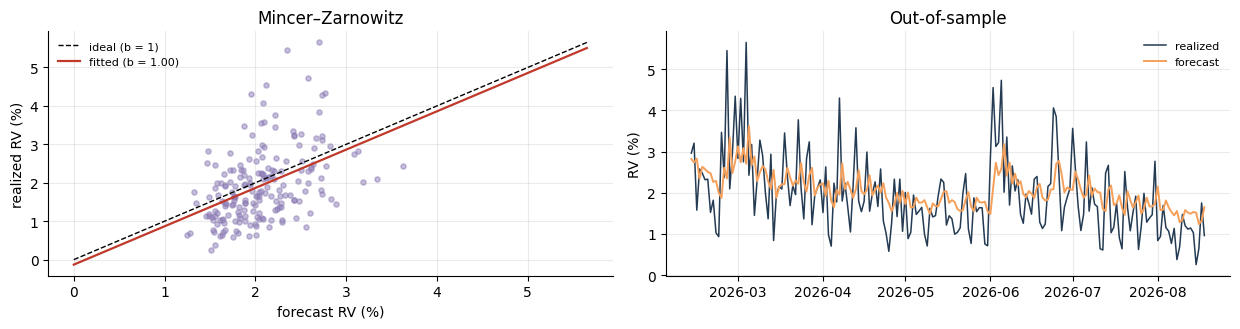

In [14]:
cut = int(len(d) * CONFIG['OOS_SPLIT'])
fit_is = sm.OLS(y.iloc[:cut], Xc.iloc[:cut]).fit()
f_oos  = np.maximum(fit_is.predict(Xc.iloc[cut:]), EPS)
a_oos  = y.iloc[cut:]

mz_X = pd.DataFrame({'const': 1.0, 'pred': np.asarray(f_oos, float)}, index=a_oos.index)
mz   = sm.OLS(a_oos, mz_X).fit(cov_type='HAC', cov_kwds={'maxlags': None})
ftest = mz.f_test('const = 0, pred = 1')

mz_a, mz_b = float(mz.params['const']), float(mz.params['pred'])
mz_p  = float(ftest.pvalue)
bias  = (f_oos.mean() / a_oos.mean() - 1) * 100

print(f'a = {mz_a:+.5f} (p = {mz.pvalues["const"]:.3f})')
print(f'b = {mz_b:.3f} (p = {mz.pvalues["pred"]:.4f})')
print(f'Joint test  H0: a=0 and b=1  ->  F = {float(ftest.statistic):.2f}, p = {mz_p:.4f}')
print(f'Mean bias: {bias:+.1f}% | out-of-sample QLIKE: {qlike(a_oos.values, f_oos.values):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.4))
lims = [0, max(f_oos.max(), a_oos.max())*100]
ax[0].scatter(f_oos*100, a_oos*100, s=14, alpha=.5, color='#8B7BB5')
ax[0].plot(lims, lims, 'k--', lw=1, label='ideal (b = 1)')
ax[0].plot(lims, mz_a*100 + mz_b*np.array(lims), color=RED, lw=1.6, label=f'fitted (b = {mz_b:.2f})')
ax[0].set_xlabel('forecast RV (%)'); ax[0].set_ylabel('realized RV (%)')
ax[0].legend(frameon=False, fontsize=8); ax[0].set_title('Mincer–Zarnowitz')
ax[1].plot(a_oos.index, a_oos*100, lw=1.1, color='#243B53', label='realized')
ax[1].plot(a_oos.index, f_oos*100, lw=1.4, color='#F5A05A', label='forecast')
ax[1].legend(frameon=False, fontsize=8); ax[1].set_ylabel('RV (%)')
ax[1].set_title('Out-of-sample')
plt.tight_layout(); plt.show()

In [15]:
if mz_p > .05:
    verdict('Unbiasedness and efficiency (MZ)', 'PASS',
            f'Joint hypothesis a=0, b=1 not rejected (p = {mz_p:.4f}). The forecast is '
            'unbiased and efficient.',
            'None. No recalibration needed.', mz_p)
else:
    direction = 'over-reacts' if mz_b < 1 else 'under-reacts'
    consequence = ('bands too wide when volatility spikes' if mz_b < 1
                   else 'bands too narrow when volatility spikes — the dangerous direction')
    verdict('Unbiasedness and efficiency (MZ)', 'WATCH' if mz_b < 1 else 'ACT',
            f'Joint hypothesis rejected (p = {mz_p:.4f}) with slope b = {mz_b:.3f} and mean bias '
            f'{bias:+.1f}%. The forecast {direction}: {consequence}.',
            f'Apply the MZ recalibration in production: sigma_adjusted = {mz_a:.5f} + '
            f'{mz_b:.3f} × sigma_raw, with coefficients re-estimated on a rolling window of past '
            'data only. Guard it so it is skipped if the slope falls outside [0.5, 1.6] — an '
            'extreme slope signals a data problem, not a bias to correct.', mz_p)

---
## 9 · Band backtest: Kupiec and Christoffersen

**What is tested.** Whether the published prediction intervals behave as advertised.

- **Kupiec** — is the *frequency* of violations equal to the nominal level?
- **Christoffersen** — are violations *independent*, or do they cluster?

**Why both are needed.** A band can have exactly correct average coverage and still fail in
streaks. Clustered violations mean several consecutive days outside the band, which happens
precisely when volatility spikes — the worst possible moment for someone sizing positions
with it. Independence is arguably the more important of the two.

**Direction matters.** Over-coverage and under-coverage are not equally bad. Over-covering
means the band is wider than necessary: it costs opportunity, not capital. Under-covering
means the user is taking more risk than they believe. The verdict below distinguishes them.

95% band backtest — 188 out-of-sample days
------------------------------------------
                           test    LR  p_value                         H0
Kupiec (unconditional coverage) 6.174   0.0130        violation rate = 5%
  Christoffersen (independence) 0.098   0.7544 violations are independent
   Conditional coverage (joint) 6.272   0.0435        both simultaneously
Observed coverage: 98.4% (nominal 95%) | 3 violations of 188 expected 9 | consecutive violations: 0


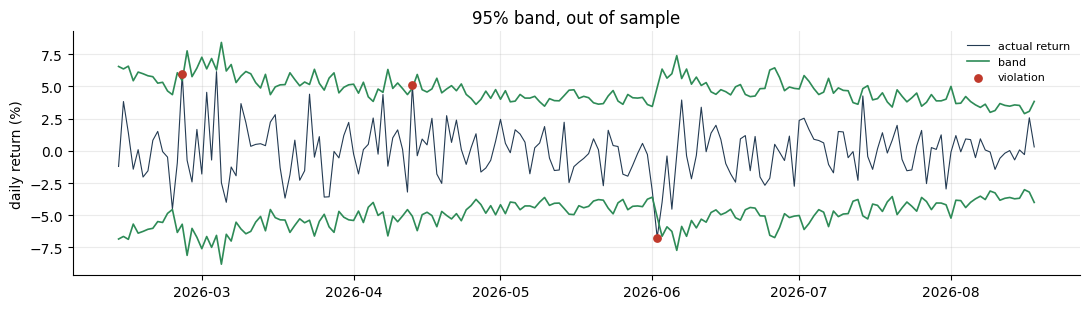

In [16]:
alpha = CONFIG['BAND_ALPHA']

# Standardised residuals from the in-sample period define the band shape
z_is = (d['ret'].iloc[:cut].values /
        np.maximum(fit_is.predict(Xc.iloc[:cut]).values, EPS))
z_is = z_is[np.isfinite(z_is)]
q_lo, q_hi = np.quantile(z_is, [alpha/2, 1 - alpha/2])

sigma_oos = np.asarray(f_oos, float)
ret_oos   = d['ret'].iloc[cut:].values
band_lo, band_hi = q_lo * sigma_oos, q_hi * sigma_oos

viol = ((ret_oos < band_lo) | (ret_oos > band_hi)).astype(int)
N, x = len(viol), int(viol.sum())
pi_obs = x / N
coverage = (1 - pi_obs) * 100

# --- Kupiec: unconditional coverage LR test ---
if 0 < x < N:
    lr_uc = -2 * ((N-x)*np.log(1-alpha) + x*np.log(alpha)
                  - (N-x)*np.log(1-pi_obs) - x*np.log(pi_obs))
    p_uc = 1 - sps.chi2.cdf(lr_uc, 1)
else:
    lr_uc, p_uc = np.nan, np.nan

# --- Christoffersen: independence LR test ---
n00 = int(np.sum((viol[:-1]==0) & (viol[1:]==0)))
n01 = int(np.sum((viol[:-1]==0) & (viol[1:]==1)))
n10 = int(np.sum((viol[:-1]==1) & (viol[1:]==0)))
n11 = int(np.sum((viol[:-1]==1) & (viol[1:]==1)))
p01 = n01/(n00+n01) if (n00+n01) else 0
p11 = n11/(n10+n11) if (n10+n11) else 0
pi_hat = (n01+n11)/(n00+n01+n10+n11) if (n00+n01+n10+n11) else 0
try:
    ll_h0 = ((n00+n10)*np.log(1-pi_hat) + (n01+n11)*np.log(pi_hat)) if 0 < pi_hat < 1 else np.nan
    ll_h1 = sum(c*np.log(p) for c, p in ((n00, 1-p01), (n01, p01), (n10, 1-p11), (n11, p11))
                if c and 0 < p < 1)
    lr_ind = -2 * (ll_h0 - ll_h1)
    p_ind  = 1 - sps.chi2.cdf(lr_ind, 1)
except Exception:
    lr_ind, p_ind = np.nan, np.nan

lr_cc = lr_uc + lr_ind if np.isfinite(lr_uc) and np.isfinite(lr_ind) else np.nan
p_cc  = 1 - sps.chi2.cdf(lr_cc, 2) if np.isfinite(lr_cc) else np.nan

bt = pd.DataFrame([
    {'test': 'Kupiec (unconditional coverage)', 'LR': round(lr_uc, 3),
     'p_value': round(p_uc, 4), 'H0': f'violation rate = {alpha*100:.0f}%'},
    {'test': 'Christoffersen (independence)',   'LR': round(lr_ind, 3),
     'p_value': round(p_ind, 4), 'H0': 'violations are independent'},
    {'test': 'Conditional coverage (joint)',    'LR': round(lr_cc, 3),
     'p_value': round(p_cc, 4),  'H0': 'both simultaneously'},
])
show_df(bt, f'{int((1-alpha)*100)}% band backtest — {N} out-of-sample days')
print(f'Observed coverage: {coverage:.1f}% (nominal {(1-alpha)*100:.0f}%) | '
      f'{x} violations of {N} expected {alpha*N:.0f} | consecutive violations: {n11}')

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(a_oos.index, ret_oos*100, lw=.8, color='#243B53', label='actual return')
ax.plot(a_oos.index, band_hi*100, lw=1.2, color=GREEN, label='band')
ax.plot(a_oos.index, band_lo*100, lw=1.2, color=GREEN)
mask = viol.astype(bool)
ax.scatter(a_oos.index[mask], ret_oos[mask]*100, color=RED, s=28, zorder=3, label='violation')
ax.legend(frameon=False, fontsize=8); ax.set_ylabel('daily return (%)')
ax.set_title(f'{int((1-alpha)*100)}% band, out of sample')
plt.tight_layout(); plt.show()

In [17]:
if np.isfinite(p_uc) and p_uc > .05:
    verdict('Kupiec — violation frequency', 'PASS',
            f'Observed coverage {coverage:.1f}% vs {(1-alpha)*100:.0f}% nominal (p = {p_uc:.4f}). '
            'The violation rate is statistically correct.',
            'None. The band can be published as stated.', p_uc)
elif pi_obs < alpha:
    verdict('Kupiec — violation frequency', 'WATCH',
            f'Observed coverage {coverage:.1f}% vs {(1-alpha)*100:.0f}% nominal (p = {p_uc:.4f}): '
            'the band is WIDER than necessary. This is the benign direction — it over-covers.',
            'No risk action required. If you want the extra precision, apply the MZ '
            'recalibration from Section 8, which shrinks the band toward its correct width. '
            'Section 10 quantifies the opportunity cost.', p_uc)
else:
    verdict('Kupiec — violation frequency', 'ACT',
            f'Observed coverage {coverage:.1f}% vs {(1-alpha)*100:.0f}% nominal (p = {p_uc:.4f}): '
            'the band UNDERSTATES risk. Users are taking more exposure than they believe.',
            'Widen the band immediately by the ratio implied in Section 10 until the live track '
            'record confirms correct coverage. Do not market the nominal figure meanwhile.', p_uc)

if np.isfinite(p_ind) and p_ind > .05:
    verdict('Christoffersen — independence', 'PASS',
            f'p = {p_ind:.4f} with {n11} consecutive violations. Failures are dispersed, which '
            'is the benign failure mode.',
            'None.', p_ind)
else:
    verdict('Christoffersen — independence', 'ACT',
            f'p = {p_ind:.4f} with {n11} consecutive violations. Violations cluster — several '
            'days in a row outside the band, exactly when volatility spikes.',
            'The conditional-volatility scaling is not reacting fast enough. Increase the weight '
            'on the daily component (shorter effective memory) or add a regime-shift override '
            'that widens the band when realized volatility exceeds its own 90th percentile.', p_ind)

---
## 10 · Business impact: what each statistical error costs

Statistics answer whether the model is correct. This section answers **what the errors mean
in dollars** for the account configured in Section 1.

The sizing rule the product publishes is:

$$\text{notional} = \frac{\text{max risk per trade}}{\text{band half-width}}$$

So a coverage error is a *sizing* error. If the band is 10% too wide, every position is 10%
too small — a permanent drag on returns that never shows up as a loss.

In [18]:
cap      = CONFIG['ACCOUNT_USD']
risk_pct = CONFIG['RISK_PCT']
cost_rt  = CONFIG['COST_RT_PCT'] / 100
last_px  = float(px['close'].iloc[-1])

sigma_now = float(np.maximum(np.asarray(hac.predict(Xc.iloc[[-1]])), EPS)[0])
half_now  = 1.96 * sigma_now                       # 95% half-width, in return units
risk_usd  = cap * risk_pct / 100
notional  = risk_usd / half_now
units     = notional / last_px

# Sizing error implied by the observed coverage miss.
# width_ratio is the factor the published half-width SHOULD be multiplied by to
# hit the nominal violation rate:
#   < 1  -> band currently too WIDE  -> positions too SMALL (opportunity cost)
#   > 1  -> band currently too NARROW -> positions too LARGE (risk)
z_nom = 1.96
z_obs = sps.norm.ppf(1 - pi_obs/2) if 0 < pi_obs < 1 else z_nom
width_ratio = z_nom / z_obs
size_error_pct = (1/width_ratio - 1) * 100     # +ve => undersized, -ve => oversized

impact = pd.DataFrame([
    {'metric': 'Forecast volatility (next day)', 'value': f'{sigma_now*100:.2f}%'},
    {'metric': '95% band half-width',            'value': f'±{half_now*100:.2f}%'},
    {'metric': 'Max risk per trade',             'value': f'${risk_usd:,.2f}'},
    {'metric': 'Implied notional',               'value': f'${notional:,.0f}'},
    {'metric': 'Implied position size',          'value': f'{units:.5f} units'},
    {'metric': 'Implied leverage',               'value': f'{notional/cap:.2f}x'},
    {'metric': 'Round-trip cost per trade',      'value': f'${notional*cost_rt:,.2f}'},
])
show_df(impact, f'Sizing implied by the model, on a ${cap:,.0f} account')

print(f'\nCoverage: nominal {(1-alpha)*100:.0f}% vs observed {coverage:.1f}%')
print(f'Band-width correction needed: x{width_ratio:.3f} '
      f'({"narrow it" if width_ratio < 1 else "widen it"})')
print(f'  -> positions are currently {abs(size_error_pct):.1f}% '
      f'{"SMALLER" if size_error_pct > 0 else "LARGER"} than the risk budget implies')
print(f'  -> notional difference: ${notional/width_ratio - notional:+,.0f} per trade')

print('\nCost of trading frequency (round-trip only, at current notional):')
for trades, label in ((250, 'daily'), (60, 'weekly'), (12, 'monthly')):
    annual = notional * cost_rt * trades
    print(f'  {label:>8} ({trades:>3} trades/yr): ${annual:>8,.2f} = '
          f'{annual/cap*100:>5.1f}% of capital per year')

# Break-even hit rate at this horizon
be = 0.5 + cost_rt / (2 * sigma_now)
print(f'\nBreak-even directional hit rate at 1-day horizon: {be*100:.1f}%')
print('  (This model does NOT forecast direction — shown only to frame the cost barrier '
      'for any directional overlay a user might add.)')

Sizing implied by the model, on a $700 account
----------------------------------------------
                        metric         value
Forecast volatility (next day)         1.57%
           95% band half-width        ±3.09%
            Max risk per trade        $14.00
              Implied notional          $454
         Implied position size 0.00701 units
              Implied leverage         0.65x
     Round-trip cost per trade         $0.62

Coverage: nominal 95% vs observed 98.4%
Band-width correction needed: x0.813 (narrow it)
  -> positions are currently 23.0% SMALLER than the risk budget implies
  -> notional difference: $+104 per trade

Cost of trading frequency (round-trip only, at current notional):
     daily (250 trades/yr): $  155.37 =  22.2% of capital per year
    weekly ( 60 trades/yr): $   37.29 =   5.3% of capital per year
   monthly ( 12 trades/yr): $    7.46 =   1.1% of capital per year

Break-even directional hit rate at 1-day horizon: 54.4%
  (This model doe

In [19]:
if width_ratio < 0.95:
    verdict('Sizing efficiency', 'WATCH',
            f'The band is about {(1/width_ratio-1)*100:.1f}% wider than the observed violation '
            f'rate justifies, so every position is that much smaller than optimal — roughly '
            f'${abs(notional/width_ratio - notional):,.0f} of foregone notional per trade. '
            'This is an opportunity cost, not a risk exposure.',
            f'Optional: apply the MZ recalibration from Section 8, or multiply the half-width by '
            f'{width_ratio:.2f}. Safe to defer until the live track record reaches ~90 '
            'observations — over-covering never harms the user.',
            float(width_ratio))
elif width_ratio > 1.05:
    verdict('Sizing efficiency', 'ACT',
            f'The band is about {(1-1/width_ratio)*100:.1f}% narrower than the observed violation '
            'rate justifies, so every position is oversized relative to the stated risk budget. '
            'Users are taking more exposure than the published number implies.',
            f'Multiply the published half-width by {width_ratio:.2f} immediately, and notify any '
            'user relying on the sizing rule. Do not defer: this is a risk exposure, not an '
            'efficiency loss.',
            float(width_ratio))
else:
    verdict('Sizing efficiency', 'PASS',
            f'Band width is within 5% of what the observed coverage implies '
            f'(ratio {width_ratio:.3f}).',
            'None. The sizing rule can be used as published.', float(width_ratio))

lev = notional / cap
if lev > 1.0:
    verdict('Implied leverage', 'WATCH',
            f'The sizing rule implies {lev:.2f}x leverage at current volatility.',
            f'Confirm the account can carry it, and note that at {lev:.1f}x an adverse move of '
            f'{50/lev:.1f}% would halve the equity. Consider lowering RISK_PCT.', float(lev))
else:
    verdict('Implied leverage', 'PASS',
            f'The sizing rule implies {lev:.2f}x leverage — below 1x at current volatility.',
            'None. The rule is self-limiting: as volatility rises, the band widens and size '
            'falls automatically.', float(lev))

---
## 11 · Dashboard and downloadable report

The decision rule below is fixed in advance:

- 🔴 on **Kupiec (under-coverage)** or **Christoffersen** → the risk budget is not
  trustworthy. Stop publishing the nominal figure until fixed.
- 🔴 on **Generalisation** → the model does not work out of sample. Fall back to a rolling
  standard deviation.
- 🟡 elsewhere → usable, with the stated action queued.

Everything else is a matter of efficiency, not safety.

In [20]:
F = pd.DataFrame(FINDINGS)
F[''] = F['status'].map({'PASS': '🟢', 'WATCH': '🟡', 'ACT': '🔴', 'INFO': '⚪'})
show_df(F[['', 'test', 'status', 'value']], 'Validation dashboard')

critical = F[(F['status'] == 'ACT') &
             (F['test'].str.contains('Kupiec|Christoffersen|Generalisation', regex=True))]
any_act  = F[F['status'] == 'ACT']

if len(critical):
    headline = ('🔴 DO NOT RELY ON THE RISK BUDGET. Critical tests failed: '
                + ', '.join(critical['test']) + '. These govern whether the published band '
                'means what it says.')
elif len(any_act):
    headline = ('🟡 USABLE, WITH REQUIRED FIXES. Non-critical tests need action: '
                + ', '.join(any_act['test']) + '. None of them compromise the safety of the '
                'risk budget, but each has a queued action.')
elif (F['status'] == 'WATCH').any():
    headline = ('🟢 MODEL VALIDATED, WITH WATCH ITEMS. Assumptions hold, the model generalises, '
                'and the bands pass formal coverage and independence testing. Queued '
                'improvements are efficiency gains, not corrections.')
else:
    headline = ('🟢 MODEL FULLY VALIDATED. Every test passed. Fit for production.')

print('=' * 80); print(headline); print('=' * 80)

print('\nACTION QUEUE (in priority order):')
for status in ('ACT', 'WATCH'):
    for _, r in F[F['status'] == status].iterrows():
        import re as _re
        print(f"  [{status:>5}] {r['test']}: {_re.sub('<[^>]+>', '', str(r['action']))}")

Validation dashboard
--------------------
                                      test status        value
🟡                   Component significance  WATCH 2.000000e+00
🟢                        Multicollinearity   PASS 2.280000e+00
🟢                         Regime alignment   PASS 1.335713e+00
🟡                 Residual autocorrelation  WATCH 2.465109e-12
⚪           Conditional heteroskedasticity   INFO 3.451588e-02
🟡                             Stationarity  WATCH 5.000000e-04
🟡                     Structural stability  WATCH 1.211382e+00
🟢 Generalisation (QLIKE skill vs baseline)   PASS 2.054000e+01
🟢           Performance drift across folds   PASS 3.000000e-01
🟢         Unbiasedness and efficiency (MZ)   PASS 6.376401e-02
🟡             Kupiec — violation frequency  WATCH 1.296365e-02
🟢            Christoffersen — independence   PASS 7.544489e-01
🟡                        Sizing efficiency  WATCH 8.133160e-01
🟢                         Implied leverage   PASS 6.480577e-01
🟢 MODEL VALID

In [21]:
import re as _re

ts = pd.Timestamp.now(tz='UTC')
L = ['# XGBit Volatility Radar — HAR-RV Model Validation Report', '',
     f'- **Generated:** {ts.strftime("%Y-%m-%d %H:%M")} UTC',
     f'- **Data source:** {SOURCE} · **Observations:** {len(d)}'
     + (f' (capped at {CONFIG["TRAIN_WINDOW"]} days to match production)'
        if CONFIG['APPLY_TRAIN_WINDOW'] else ' (FULL history — not what production uses)'),
     f'- **Period:** {d.index[0].date()} → {d.index[-1].date()}',
     f'- **Account assumptions:** ${cap:,.0f} capital · {risk_pct}% risk/trade · '
     f'{CONFIG["COST_RT_PCT"]}% round-trip cost', '',
     '## Verdict', '', headline, '',
     '## Dashboard', '', '| Test | Status | Value |', '|---|---|---|']
for _, r in F.iterrows():
    v = r['value']
    v = f'{v:.4f}' if isinstance(v, (int, float, np.floating)) and np.isfinite(v) else '—'
    L.append(f"| {r['test']} | **{r['status']}** | {v} |")

L += ['', '## Findings and actions', '']
for _, r in F.iterrows():
    L += [f"### {r['status']} — {r['test']}", '',
          f"**Finding:** {_re.sub('<[^>]+>', '', str(r['finding']))}", '',
          f"**Action:** {_re.sub('<[^>]+>', '', str(r['action']))}", '']

L += ['## Estimation (HAC standard errors)', '', '```', est.to_string(index=False), '```',
      f'- R² = {hac.rsquared:.4f} · adjusted R² = {hac.rsquared_adj:.4f} · n = {int(hac.nobs)}',
      f'- Persistence (b_d+b_w+b_m) = {persistence:.4f}',
      f'- HAC errors are {se_inflation:.2f}x the classical ones', '',
      '## Variance inflation', '', '```', vif.to_string(index=False), '```', '',
      '## Regime alignment', '', '```', align.to_string(index=False), '```',
      f'- Misalignment factor: {misalign:.2f}x · intercept share of forecast: '
      f'{intercept_share:.0f}%',
      f'- Training window used: {len(d)} days '
      f'({"capped to match production" if CONFIG["APPLY_TRAIN_WINDOW"] else "FULL history"})', '',
      '## Residual diagnostics', '', '```', diag.to_string(index=False), '```', '',
      '```', lb.round(4).reset_index().to_string(index=False), '```', '',
      '## Stationarity', '', '```', stat.to_string(index=False), '```', '',
      '## Parameter stability', '', '```', stab.to_string(index=False), '```',
      f'- CUSUM maximum: {cusum_max:.3f} (5% critical value: {CUSUM_CRIT})', '',
      '## Cross-validation', '', '```', cv.to_string(index=False), '```',
      f'- Mean QLIKE {cv["QLIKE"].mean():.4f} vs baseline {cv["QLIKE_base"].mean():.4f} · '
      f'skill {skill:+.1f}% · model wins {folds_won}/{len(cv)} folds',
      f'- In-sample R² {r2_in:.4f} · out-of-sample R² {r2_oos:.4f} (unstable on short blocks)',
      '',
      '## Mincer–Zarnowitz', '',
      f'- a = {mz_a:+.5f}, b = {mz_b:.3f}, R² = {mz.rsquared:.4f}',
      f'- Joint test (a=0, b=1): F = {float(ftest.statistic):.2f}, p = {mz_p:.4f}',
      f'- Mean bias: {bias:+.1f}%', '',
      '## Band backtest', '', '```', bt.to_string(index=False), '```',
      f'- Observed coverage {coverage:.1f}% (nominal {(1-alpha)*100:.0f}%), '
      f'{x} violations of {N}, {n11} consecutive', '',
      '## Business impact', '', '```', impact.to_string(index=False), '```',
      f'- Band-width correction needed: x{width_ratio:.3f} '
      f'(positions currently {abs(size_error_pct):.1f}% '
      f'{"undersized" if size_error_pct > 0 else "oversized"})',
      f'- Implied leverage: {lev:.2f}x',
      f'- Round-trip cost per trade: ${notional*cost_rt:,.2f}', '',
      '---', '*Generated by HARRV_Model_Validation_EN.ipynb*']

report = chr(10).join(L)
fname = f'HARRV_Validation_{ts.strftime("%Y%m%d")}.md'
with open(fname, 'w', encoding='utf-8') as fh:
    fh.write(report)

print(f'Report written: {fname} ({len(report):,} characters)')
print(f'Location: {os.path.abspath(fname)}')
try:
    from google.colab import files as _cf
    _cf.download(fname)
except Exception:
    try:
        from IPython.display import FileLink
        display(FileLink(fname, result_html_prefix='Download here: '))
    except Exception:
        pass

Report written: HARRV_Validation_20260819.md (9,172 characters)
Location: C:\projects\BTC-Risk-Bands\HARRV_Validation_20260819.md


C:\projects\BTC-Risk-Bands\HARRV_Validation_20260819.md

---
## How to use this notebook operationally

**Cadence.** Run it monthly, and always after any change to the model, the training window,
or the data source.

**What to compare.** The dashboard is more informative as a time series than as a snapshot.
Keep the generated reports and watch three numbers: observed coverage, the MZ slope, and the
out-of-sample R². Coverage drifting away from nominal is the earliest warning that the market
regime has moved.

**Relationship to the daily monitor.** `monitor.py` answers *"did yesterday's band contain
today's close?"* — one observation at a time, accumulating an auditable track record. This
notebook answers *"is the model still correctly specified?"* — the structural question. Both
are needed: the monitor catches degradation, the notebook explains it.

**When live data supersedes this.** Once the live track record reaches ~90 evaluated days,
its coverage figure is the one to quote publicly. The out-of-sample numbers here are an
estimate; the track record is a measurement.